# Modelo de Regresión — Predicción de Consumo Energético (Smart Lighting)
<br>

**Objetivo:** Desarrollar modelos de regresión para predecir el consumo energético (`energy_consumption_kwh`) en un sistema de iluminación inteligente.

**Modelos a implementar:**
- Regresión Lineal
- XGBoost Regressor
- RANSAC Regressor
- Support Vector Regression (SVR)

**Dataset:** `datos_limpios_SmartLighting.csv` (12,000 muestras, 23 columnas)

## 1. Importar las librerías necesarias

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Preprocesamiento y selección
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold,
    cross_validate, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

# Modelos
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import pickle

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar los datos limpios

In [2]:
# Cargar el dataset limpio
df = pd.read_csv('../data/datos_limpios_SmartLighting.csv')

print("Datos cargados:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
df.head()

Datos cargados:
Dimensiones: (12000, 23)

Columnas:
['zone_id', 'ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'special_event_flag', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity', 'energy_consumption_kwh', 'lighting_action_class', 'hour', 'month', 'is_weekend', 'season', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']

Primeras 5 filas:


,zone_id,ambient_light_lux,motion_detected,temperature_celsius,occupancy_count,day_of_week,time_of_day,special_event_flag,energy_price_per_kwh,prev_hour_energy_usage_kwh,...,energy_consumption_kwh,lighting_action_class,hour,month,is_weekend,season,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Foggy,weather_condition_Rainy
0,3,-0.993840,0,-0.460746,-0.257032,1,4,0,-0.946558,0.399885,...,1.144,0,0,1,0,1,0,1,0,0
1,3,-0.983895,0,-0.922368,-0.464636,1,4,0,-0.333568,-0.576984,...,2.069,1,0,1,0,1,0,1,0,0
2,7,-0.993840,0,0.449719,0.158177,1,4,0,-0.647922,-0.019562,...,1.687,1,1,1,0,1,1,0,0,0
3,2,-0.993840,1,1.301084,1.611408,1,4,0,0.884553,-1.217192,...,1.631,1,2,1,0,1,0,0,1,0
4,4,-0.993840,1,0.336310,0.573386,1,4,0,0.538764,-0.565946,...,1.737,1,2,1,0,1,1,0,0,0


## 3. Verificación de los datos preprocesados

In [3]:
# Información del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zone_id                     12000 non-null  int64  
 1   ambient_light_lux           12000 non-null  float64
 2   motion_detected             12000 non-null  int64  
 3   temperature_celsius         12000 non-null  float64
 4   occupancy_count             12000 non-null  float64
 5   day_of_week                 12000 non-null  int64  
 6   time_of_day                 12000 non-null  int64  
 7   special_event_flag          12000 non-null  int64  
 8   energy_price_per_kwh        12000 non-null  float64
 9   prev_hour_energy_usage_kwh  12000 non-null  float64
 10  traffic_density             12000 non-null  float64
 11  avg_pedestrian_speed        12000 non-null  float64
 12  adjusted_light_intensity    12000 non-null  float64
 13  energy_consumptio

In [4]:
# Verificar valores faltantes
print("Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

Valores faltantes:
No hay valores faltantes


Estadísticas de la variable objetivo (energy_consumption_kwh):
count    12000.000000
mean         1.483592
std          0.538188
min          0.000000
25%          1.047000
50%          1.595000
75%          1.907000
max          2.887000
Name: energy_consumption_kwh, dtype: float64


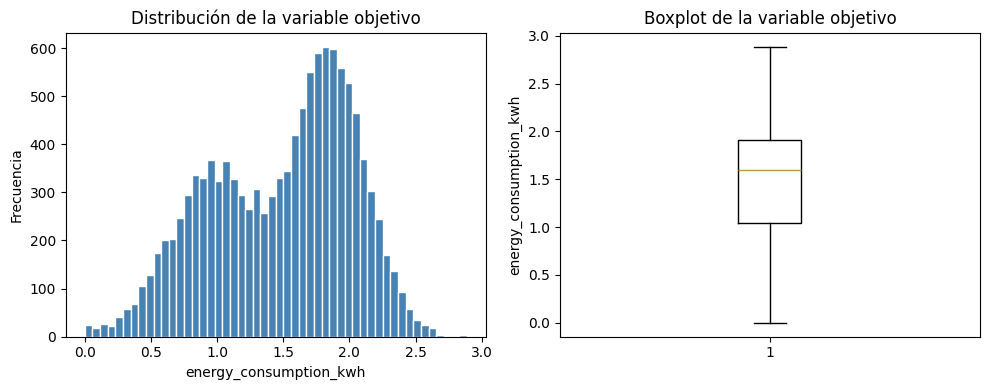

In [5]:
# Distribución de la variable objetivo
print("Estadísticas de la variable objetivo (energy_consumption_kwh):")
print(df['energy_consumption_kwh'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['energy_consumption_kwh'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('energy_consumption_kwh')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable objetivo')

plt.subplot(1, 2, 2)
plt.boxplot(df['energy_consumption_kwh'])
plt.ylabel('energy_consumption_kwh')
plt.title('Boxplot de la variable objetivo')

plt.tight_layout()
plt.show()

## 4. Preparación de los datos para modelado

### 4.1 Separar features (X) y variable objetivo (y)

In [6]:
# Separar features y target
# Se excluye 'lighting_action_class' ya que es una variable de clasificación derivada
X = df.drop(['energy_consumption_kwh', 'lighting_action_class'], axis=1)
y = df['energy_consumption_kwh']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nFeatures utilizadas ({len(X.columns)}):")
print(X.columns.tolist())

Shape de X (features): (12000, 21)
Shape de y (target): (12000,)

Features utilizadas (21):
['zone_id', 'ambient_light_lux', 'motion_detected', 'temperature_celsius', 'occupancy_count', 'day_of_week', 'time_of_day', 'special_event_flag', 'energy_price_per_kwh', 'prev_hour_energy_usage_kwh', 'traffic_density', 'avg_pedestrian_speed', 'adjusted_light_intensity', 'hour', 'month', 'is_weekend', 'season', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy']


### 4.2 División en conjuntos de entrenamiento y prueba

In [7]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f"  - Prueba:        {X_test.shape[0]} muestras ({(len(X_test)/len(X))*100:.1f}%)")
print(f"\nEstadísticas de y_train:")
print(y_train.describe())
print(f"\nEstadísticas de y_test:")
print(y_test.describe())

División de datos:
  - Entrenamiento: 9600 muestras (80.0%)
  - Prueba:        2400 muestras (20.0%)

Estadísticas de y_train:
count    9600.000000
mean        1.485461
std         0.536915
min         0.000000
25%         1.052000
50%         1.595000
75%         1.907000
max         2.887000
Name: energy_consumption_kwh, dtype: float64

Estadísticas de y_test:
count    2400.000000
mean        1.476120
std         0.543295
min         0.000000
25%         1.026750
50%         1.594500
75%         1.906250
max         2.886000
Name: energy_consumption_kwh, dtype: float64


### 4.3 Escalado de features

In [8]:
# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con train y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print(f"\nEstadísticas después del escalado (train):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))


Estadísticas después del escalado (train):
      zone_id  ambient_light_lux  motion_detected  temperature_celsius  \
mean     -0.0               -0.0              0.0                 -0.0   
std       1.0                1.0              1.0                  1.0   

      occupancy_count  day_of_week  time_of_day  special_event_flag  \
mean             -0.0         -0.0          0.0                 0.0   
std               1.0          1.0          1.0                 1.0   

      energy_price_per_kwh  prev_hour_energy_usage_kwh  ...  \
mean                  -0.0                        -0.0  ...   
std                    1.0                         1.0  ...   

      avg_pedestrian_speed  adjusted_light_intensity  hour  month  is_weekend  \
mean                  -0.0                      -0.0  -0.0   -0.0        -0.0   
std                    1.0                       1.0   1.0    1.0         1.0   

      season  weather_condition_Clear  weather_condition_Cloudy  \
mean    -0.0      

## supuestos de linealidad para regresion lineal multiple

## 5. Modelo 1: Regresión Lineal

### 5.1 Modelo base (sin optimización)

In [9]:
# TODO: Implementar Regresión Lineal base
pass

### 5.2 Optimización


In [10]:
# TODO: Optimización de Regresión Lineal
pass

### 5.3 Gráfico de predicciones — Regresión Lineal

In [11]:
# TODO: Visualización Regresión Lineal
pass

## 6. Modelo 2: XGBoost Regressor

### 6.1 Modelo base (sin optimización)

In [12]:
# Entrenar XGBoost con parámetros por defecto
# XGBoost no requiere datos escalados
xgb_base = XGBRegressor(random_state=RANDOM_STATE)
xgb_base.fit(X_train, y_train)

# Predicciones
y_pred_xgb_base = xgb_base.predict(X_test)

# Métricas de regresión
print("RESULTADOS XGBOOST BASE")
print(f"MAE  (Error Absoluto Medio)       : {mean_absolute_error(y_test, y_pred_xgb_base):.4f}")
print(f"MSE  (Error Cuadrático Medio)      : {mean_squared_error(y_test, y_pred_xgb_base):.4f}")
print(f"RMSE (Raíz del Error Cuadrático)   : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_base)):.4f}")
print(f"R²   (Coeficiente de determinación): {r2_score(y_test, y_pred_xgb_base):.4f}")
print(f"MAPE (Error Porcentual Absoluto)   : {mean_absolute_percentage_error(y_test, y_pred_xgb_base)*100:.2f}%")

RESULTADOS XGBOOST BASE
MAE  (Error Absoluto Medio)       : 0.1767
MSE  (Error Cuadrático Medio)      : 0.0493
RMSE (Raíz del Error Cuadrático)   : 0.2221
R²   (Coeficiente de determinación): 0.8328
MAPE (Error Porcentual Absoluto)   : 179461139988500.72%


### 6.2 Optimización con Grid Search

Hiperparámetros importantes de XGBoost Regressor:
- `n_estimators`: Número de árboles — más árboles mejoran el rendimiento pero aumentan el tiempo de entrenamiento
- `max_depth`: Profundidad máxima de cada árbol — controla la complejidad del modelo
- `learning_rate`: Tasa de aprendizaje — valores bajos requieren más árboles pero generalizan mejor
- `subsample`: Fracción de muestras usadas por árbol — reduce overfitting
- `colsample_bytree`: Fracción de features usadas por árbol — reduce overfitting

In [13]:
# Definir la grilla de hiperparámetros
param_grid_xgb = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [3, 5, 7],
    'learning_rate'  : [0.01, 0.1, 0.3],
    'subsample'      : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Grilla de hiperparámetros para XGBoost Regressor:")
print(param_grid_xgb)
total = 1
for v in param_grid_xgb.values():
    total *= len(v)
print(f"\nTotal de combinaciones: {total}")
print(f"Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo")

Grilla de hiperparámetros para XGBoost Regressor:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0]}

Total de combinaciones: 243
Se usará una muestra del 30% del set de entrenamiento para reducir el tiempo


In [14]:
# Muestra del 30% para Grid Search (misma estrategia que en el modelo de anomalías)
X_train_xgb_sample, _, y_train_xgb_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE
)

print(f"Tamaño del dataset de entrenamiento completo : {len(X_train):,}")
print(f"Tamaño de la muestra para Grid Search        : {len(X_train_xgb_sample):,}")

cv_strategy_xgb = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_xgb,
    cv=cv_strategy_xgb,
    scoring='neg_root_mean_squared_error',  # Optimizar RMSE
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train_xgb_sample, y_train_xgb_sample)
print("\nGrid Search completado")

Tamaño del dataset de entrenamiento completo : 9,600
Tamaño de la muestra para Grid Search        : 2,880
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Grid Search completado


In [15]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS XGBOOST REGRESSOR")
print(f"Mejores parámetros : {grid_search_xgb.best_params_}")
print(f"Mejor RMSE (CV)    : {-grid_search_xgb.best_score_:.4f}")

# Modelo final entrenado con todos los datos de entrenamiento
xgb_best = XGBRegressor(
    n_estimators     = grid_search_xgb.best_params_['n_estimators'],
    max_depth        = grid_search_xgb.best_params_['max_depth'],
    learning_rate    = grid_search_xgb.best_params_['learning_rate'],
    subsample        = grid_search_xgb.best_params_['subsample'],
    colsample_bytree = grid_search_xgb.best_params_['colsample_bytree'],
    random_state     = RANDOM_STATE
)

xgb_best.fit(X_train, y_train)
print("\nModelo final XGBoost entrenado con todos los datos de entrenamiento")

MEJORES HIPERPARÁMETROS XGBOOST REGRESSOR
Mejores parámetros : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Mejor RMSE (CV)    : 0.2037

Modelo final XGBoost entrenado con todos los datos de entrenamiento


In [16]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgb_best = xgb_best.predict(X_test)

print("RESULTADOS XGBOOST OPTIMIZADO (TEST SET)")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb_best):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_xgb_best):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb_best):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_xgb_best)*100:.2f}%")

RESULTADOS XGBOOST OPTIMIZADO (TEST SET)
MAE  : 0.1652
MSE  : 0.0430
RMSE : 0.2073
R²   : 0.8544
MAPE : 196456647142078.06%


### 6.3 Gráfico de predicciones — XGBoost

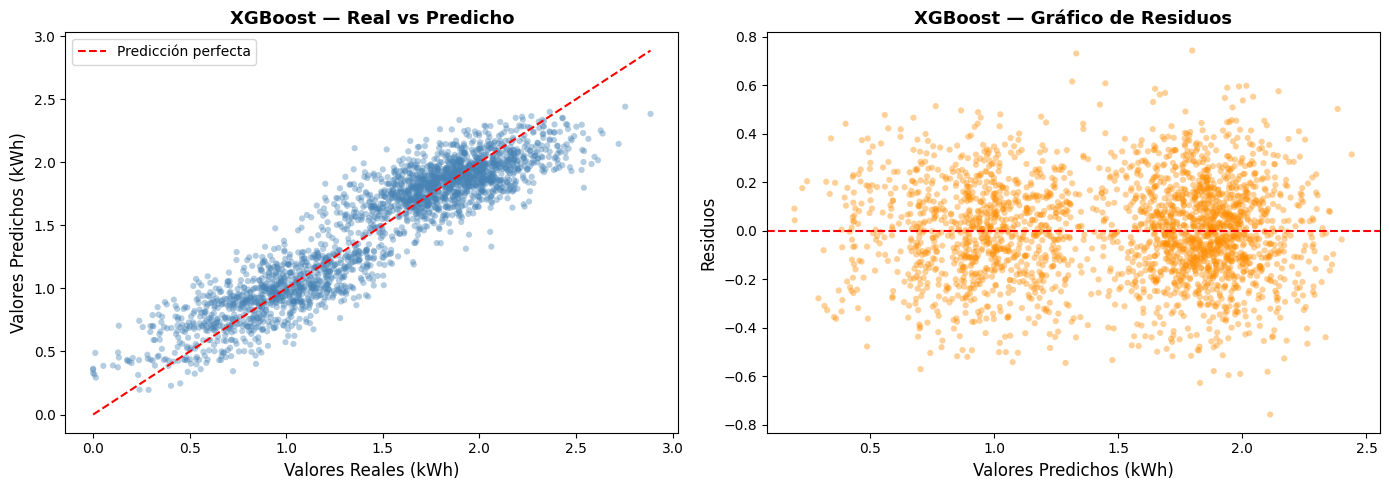

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico real vs predicho
axes[0].scatter(y_test, y_pred_xgb_best, alpha=0.4, color='steelblue', edgecolor='none', s=20)
lim = [min(y_test.min(), y_pred_xgb_best.min()),
       max(y_test.max(), y_pred_xgb_best.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales (kWh)', fontsize=12)
axes[0].set_ylabel('Valores Predichos (kWh)', fontsize=12)
axes[0].set_title('XGBoost — Real vs Predicho', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Gráfico de residuos
residuos = y_test - y_pred_xgb_best
axes[1].scatter(y_pred_xgb_best, residuos, alpha=0.4, color='darkorange', edgecolor='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valores Predichos (kWh)', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('XGBoost — Gráfico de Residuos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.4 Importancia de features (XGBoost)

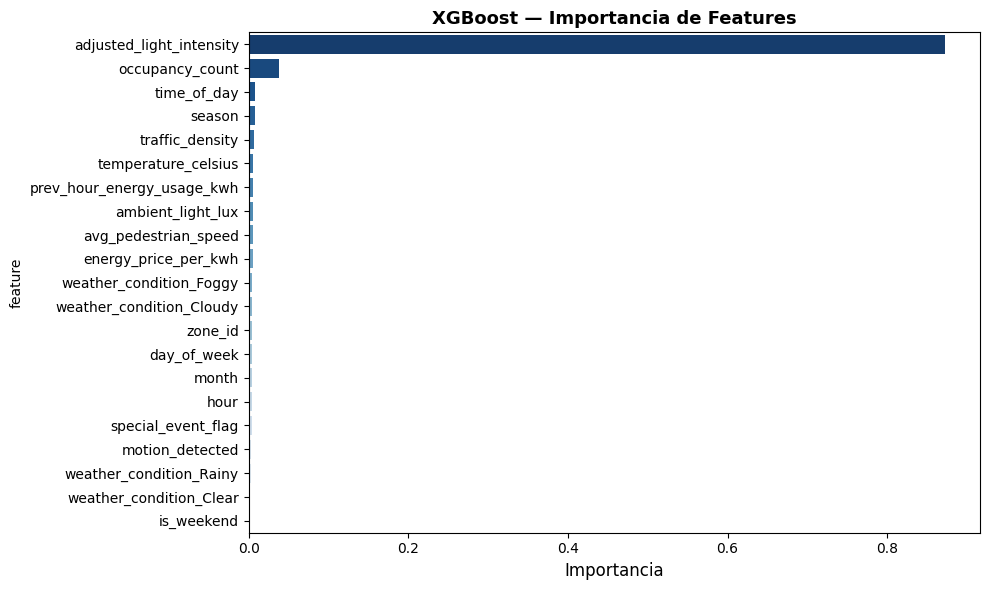

                   feature  importance
  adjusted_light_intensity    0.872625
           occupancy_count    0.038215
               time_of_day    0.007730
                    season    0.007655
           traffic_density    0.007056
       temperature_celsius    0.005683
prev_hour_energy_usage_kwh    0.005616
         ambient_light_lux    0.005443
      avg_pedestrian_speed    0.005296
      energy_price_per_kwh    0.004893
   weather_condition_Foggy    0.004770
  weather_condition_Cloudy    0.004738
                   zone_id    0.004709
               day_of_week    0.004697
                     month    0.004694
                      hour    0.004356
        special_event_flag    0.004144
           motion_detected    0.003063
   weather_condition_Rainy    0.002818
   weather_condition_Clear    0.001799
                is_weekend    0.000000


In [18]:
# Obtener importancia de features
feature_importance_xgb = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_xgb,
    x='importance', y='feature',
    palette='Blues_r'
)
plt.xlabel('Importancia', fontsize=12)
plt.title('XGBoost — Importancia de Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feature_importance_xgb.to_string(index=False))

## 7. Modelo 3: RANSAC Regressor

### 7.1 Modelo base (sin optimización)

In [19]:
# TODO: Implementar RANSAC Regressor base
pass

### 7.2 Optimización

In [20]:
# TODO: Optimización RANSAC Regressor
pass

### 7.3 Gráfico de predicciones — RANSAC

In [21]:
# TODO: Visualización RANSAC
pass

## 8. Modelo 4: Support Vector Regression (SVR)

### 8.1 Modelo base (sin optimización)

In [22]:
# TODO: Implementar SVR base
pass

### 8.2 Optimización con Grid Search

In [23]:
# TODO: Grid Search SVR
pass

### 8.3 Gráfico de predicciones — SVR

In [24]:
# TODO: Visualización SVR
pass

## 9. Comparación de modelos: Regresión Lineal vs XGBoost vs RANSAC vs SVR

In [25]:
# TODO: Tabla comparativa de los 4 modelos (base + optimizado)
# Métricas: MAE, MSE, RMSE, R², MAPE
pass

In [26]:
# TODO: Visualización comparativa (barras por métrica)
pass

## 10. Selección de Características y Validación Cruzada — Regresión Lineal

TODO: Implementar selección de características para Regresión Lineal

### 10.1 Regresión Lineal — Selección de características

In [27]:
# TODO: Selección de características — Regresión Lineal
pass

### 10.2 Validación cruzada — Regresión Lineal con todas las features

In [28]:
# TODO: CV Regresión Lineal completa
pass

### 10.3 Validación cruzada — Regresión Lineal con selección de características

In [29]:
# TODO: CV Regresión Lineal con features seleccionadas
pass

### 10.4 Comparación de la validación cruzada — Regresión Lineal

In [30]:
# TODO: Tabla comparativa CV Regresión Lineal
pass

## 11. Selección de Características y Validación Cruzada — XGBoost

Se aplica selección por importancia de features (umbral = media) usando `SelectFromModel`.
XGBoost calcula internamente cuánto contribuye cada feature a la reducción del error;
se conservan las que superan el promedio de importancia.

### 11.1 XGBoost — Selección por Importancia de Features (Umbral = media)

`SelectFromModel` con `threshold='mean'` conserva únicamente las features cuya importancia
supera el promedio de todas las importancias.

In [31]:
# SelectFromModel con threshold='mean'
selector_xgb = SelectFromModel(
    estimator = xgb_best,
    threshold = 'mean',  # umbral = importancia promedio
    prefit    = True     # xgb_best ya está entrenado
)

# Aplicar selección a train y test
X_train_xgb_fs = selector_xgb.transform(X_train)
X_test_xgb_fs  = selector_xgb.transform(X_test)

# Identificar features seleccionadas y descartadas
features_seleccionadas_xgb = X.columns[selector_xgb.get_support()].tolist()
features_descartadas_xgb   = X.columns[~selector_xgb.get_support()].tolist()

umbral_xgb = xgb_best.feature_importances_.mean()
print(f"Umbral de importancia (promedio): {umbral_xgb:.4f}")

print(f"\nFeatures SELECCIONADAS ({len(features_seleccionadas_xgb)}):")
for f in features_seleccionadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

print(f"\nFeatures DESCARTADAS ({len(features_descartadas_xgb)}):")
for f in features_descartadas_xgb:
    imp = xgb_best.feature_importances_[list(X.columns).index(f)]
    print(f"  {f:35s}  importancia: {imp:.4f}")

Umbral de importancia (promedio): 0.0476

Features SELECCIONADAS (1):
  adjusted_light_intensity             importancia: 0.8726

Features DESCARTADAS (20):
  zone_id                              importancia: 0.0047
  ambient_light_lux                    importancia: 0.0054
  motion_detected                      importancia: 0.0031
  temperature_celsius                  importancia: 0.0057
  occupancy_count                      importancia: 0.0382
  day_of_week                          importancia: 0.0047
  time_of_day                          importancia: 0.0077
  special_event_flag                   importancia: 0.0041
  energy_price_per_kwh                 importancia: 0.0049
  prev_hour_energy_usage_kwh           importancia: 0.0056
  traffic_density                      importancia: 0.0071
  avg_pedestrian_speed                 importancia: 0.0053
  hour                                 importancia: 0.0044
  month                                importancia: 0.0047
  is_weekend     

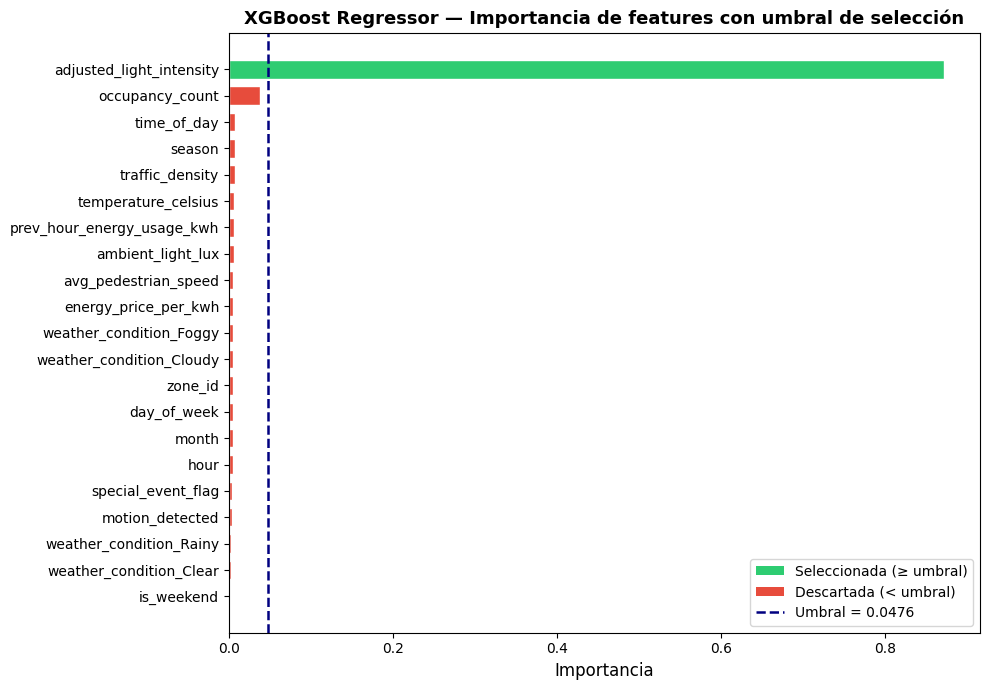

In [32]:
# Gráfica de importancias con línea de umbral
feature_imp_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=True)

colores = ['#2ecc71' if imp >= umbral_xgb else '#e74c3c'
           for imp in feature_imp_df['importance']]

plt.figure(figsize=(10, 7))
plt.barh(feature_imp_df['feature'], feature_imp_df['importance'],
         color=colores, edgecolor='white', height=0.7)
plt.axvline(x=umbral_xgb, color='navy', linestyle='--', linewidth=1.8,
            label=f'Umbral (mean = {umbral_xgb:.4f})')
plt.xlabel('Importancia', fontsize=12)
plt.title('XGBoost Regressor — Importancia de features con umbral de selección',
          fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Seleccionada (≥ umbral)'),
    Patch(facecolor='#e74c3c', label='Descartada (< umbral)'),
    plt.Line2D([0], [0], color='navy', linestyle='--',
               linewidth=1.8, label=f'Umbral = {umbral_xgb:.4f}')
]
plt.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

In [33]:
# Reentrenar XGBoost con los hiperparámetros ya optimizados y las features seleccionadas
xgb_fs = XGBRegressor(
    n_estimators     = grid_search_xgb.best_params_['n_estimators'],
    max_depth        = grid_search_xgb.best_params_['max_depth'],
    learning_rate    = grid_search_xgb.best_params_['learning_rate'],
    subsample        = grid_search_xgb.best_params_['subsample'],
    colsample_bytree = grid_search_xgb.best_params_['colsample_bytree'],
    random_state     = RANDOM_STATE
)
xgb_fs.fit(X_train_xgb_fs, y_train)

# Predicciones
y_pred_xgb_fs = xgb_fs.predict(X_test_xgb_fs)

n_features_total = X_train.shape[1]
print("RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA")
print(f"Features usadas : {len(features_seleccionadas_xgb)} de {n_features_total}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb_fs):.4f}")
print(f"MSE  : {mean_squared_error(y_test, y_pred_xgb_fs):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_fs)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb_fs):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_xgb_fs)*100:.2f}%")

RESULTADOS XGBOOST — CON SELECCIÓN POR IMPORTANCIA
Features usadas : 1 de 21
MAE  : 0.1731
MSE  : 0.0475
RMSE : 0.2179
R²   : 0.8390
MAPE : 217405517900478.47%


In [34]:
# Comparación: XGBoost completo vs XGBoost con selección por importancia
comparacion_xgb_fs = pd.DataFrame({
    'Modelo'      : [
        'XGBoost Optimizado (todas las features)',
        f'XGBoost + Importancia ({len(features_seleccionadas_xgb)} features, umbral=mean)'
    ],
    'N° Features' : [n_features_total, len(features_seleccionadas_xgb)],
    'MAE'         : [mean_absolute_error(y_test, y_pred_xgb_best),
                     mean_absolute_error(y_test, y_pred_xgb_fs)],
    'RMSE'        : [np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)),
                     np.sqrt(mean_squared_error(y_test, y_pred_xgb_fs))],
    'R²'          : [r2_score(y_test, y_pred_xgb_best),
                     r2_score(y_test, y_pred_xgb_fs)],
    'MAPE (%)'    : [mean_absolute_percentage_error(y_test, y_pred_xgb_best)*100,
                     mean_absolute_percentage_error(y_test, y_pred_xgb_fs)*100]
})

print("Comparación XGBoost — todas las features vs Selección por Importancia:")
print(comparacion_xgb_fs.round(4).to_string(index=False))

Comparación XGBoost — todas las features vs Selección por Importancia:
                                         Modelo  N° Features    MAE   RMSE     R²     MAPE (%)
        XGBoost Optimizado (todas las features)           21 0.1652 0.2073 0.8544 1.964566e+14
XGBoost + Importancia (1 features, umbral=mean)            1 0.1731 0.2179 0.8390 2.174055e+14


### 11.2 Validación cruzada — XGBoost con todas las features

In [35]:
cv_5fold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics_reg = {
    'mae'  : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2'   : 'r2'
}

t0 = time.time()

cv_results_xgb_completo = cross_validate(
    xgb_best,
    X_train, y_train,           # XGBoost no requiere datos escalados
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True     # Permite detectar overfitting
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_xgb_completo[f'test_{key}']
    train_scores = cv_results_xgb_completo[f'train_{key}']
    # MAE y RMSE vienen en negativo (neg_*), se invierten para mostrar el valor real
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST TODAS LAS FEATURES
  MAE   | Val: 0.1606 ± 0.0018 | Train: 0.1527 ± 0.0007
  RMSE  | Val: 0.2010 ± 0.0029 | Train: 0.1911 ± 0.0008
  R²    | Val: 0.8596 ± 0.0053 | Train: 0.8733 ± 0.0013

Tiempo: 0.3s


### 11.3 Validación cruzada — XGBoost con Selección por Importancia

In [36]:
t0 = time.time()
# Validación cruzada con el modelo XGBoost entrenado solo con las features
# seleccionadas por importancia (umbral = mean)
cv_results_xgb_fs = cross_validate(
    xgb_fs,
    X_train_xgb_fs, y_train,    # Subconjunto ya transformado por SelectFromModel
    cv=cv_5fold,
    scoring=scoring_metrics_reg,
    n_jobs=-1,
    return_train_score=True
)

print("\nRESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA")
for metrica, key in [('MAE', 'mae'), ('RMSE', 'rmse'), ('R²', 'r2')]:
    val_scores   = cv_results_xgb_fs[f'test_{key}']
    train_scores = cv_results_xgb_fs[f'train_{key}']
    factor = -1 if key in ['mae', 'rmse'] else 1
    print(f"  {metrica:5s} | Val: {factor*val_scores.mean():.4f} ± {val_scores.std():.4f} "
          f"| Train: {factor*train_scores.mean():.4f} ± {train_scores.std():.4f}")

print(f"\nTiempo: {time.time()-t0:.1f}s")


RESULTADOS VALIDACIÓN CRUZADA — XGBOOST CON SELECCIÓN POR IMPORTANCIA
  MAE   | Val: 0.1689 ± 0.0024 | Train: 0.1665 ± 0.0006
  RMSE  | Val: 0.2118 ± 0.0030 | Train: 0.2088 ± 0.0007
  R²    | Val: 0.8442 ± 0.0053 | Train: 0.8488 ± 0.0012

Tiempo: 0.2s


### 11.4 Comparación de la validación cruzada — XGBoost

In [37]:
metricas_cv  = ['mae', 'rmse', 'r2']
nombres_show = ['MAE', 'RMSE', 'R²']
# Las métricas neg_* se invierten para mostrar valores positivos
factores     = [-1, -1, 1]

resumen_cv_xgb = pd.DataFrame({
    'Métrica'            : nombres_show,
    'XGB_Completo_Media' : [factores[i] * cv_results_xgb_completo[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'XGB_Completo_Std'   : [cv_results_xgb_completo[f'test_{m}'].std()
                            for m in metricas_cv],
    'XGB_FS_Media'       : [factores[i] * cv_results_xgb_fs[f'test_{m}'].mean()
                            for i, m in enumerate(metricas_cv)],
    'XGB_FS_Std'         : [cv_results_xgb_fs[f'test_{m}'].std()
                            for m in metricas_cv],
})

print("COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia")
print(resumen_cv_xgb.round(4).to_string(index=False))

COMPARACIÓN VALIDACIÓN CRUZADA — XGBoost Completo vs XGBoost + Importancia
Métrica  XGB_Completo_Media  XGB_Completo_Std  XGB_FS_Media  XGB_FS_Std
    MAE              0.1606            0.0018        0.1689      0.0024
   RMSE              0.2010            0.0029        0.2118      0.0030
     R²              0.8596            0.0053        0.8442      0.0053



## 12. Selección de Características y Validación Cruzada — RANSAC

TODO: Implementar selección de características y CV para RANSAC

### 12.1 RANSAC — Selección de características

In [38]:
# TODO: Selección de características — RANSAC
pass

### 12.2 Validación cruzada — RANSAC con todas las features

In [39]:
# TODO: CV RANSAC completo
pass

### 12.3 Validación cruzada — RANSAC con selección de características

In [40]:
# TODO: CV RANSAC con features seleccionadas
pass

### 12.4 Comparación de la validación cruzada — RANSAC

In [41]:
# TODO: Tabla comparativa CV RANSAC
pass

## 13. Selección de Características y Validación Cruzada — SVR

TODO: Implementar selección de características y CV para SVR

### 13.1 SVR — Selección de características

In [42]:
# TODO: Selección de características — SVR
pass

### 13.2 Validación cruzada — SVR con todas las features

In [43]:
# TODO: CV SVR completo
pass

### 13.3 Validación cruzada — SVR con selección de características

In [44]:
# TODO: CV SVR con features seleccionadas
pass

### 13.4 Comparación de la validación cruzada — SVR

In [45]:
# TODO: Tabla comparativa CV SVR
pass

## 14. Comparación final con validación cruzada

Se comparan los 4 modelos en:
1. Métricas en test set: modelos completos y con selección de features
2. Validación cruzada 5-fold: comparación de MAE, RMSE y R²
3. Número de features seleccionadas por cada método

### 14.1 Comparación de métricas en test set

In [46]:
# TODO: Tabla comparativa final — todos los modelos (completos + con FS)
# Métricas: MAE, RMSE, R², MAPE
pass

### 14.2 Selección de variables

In [47]:
# TODO: Resumen del número de features seleccionadas por cada modelo
pass

### 14.3 Validación cruzada

In [48]:
# TODO: Tabla comparativa CV — los 4 modelos (completo + con FS)
pass

### 14.4 Gráficos de Validación Cruzada: RMSE y R²

In [49]:
# TODO: Gráficos comparativos de CV (RMSE y R²) para los 4 modelos
pass

## 15. Guardar modelos

*(Pendiente — se activará cuando todos los modelos estén finalizados)*

In [50]:
# guardar modelos
# import pickle

# with open('modelo_xgb_regressor.pkl', 'wb') as f:
#     pickle.dump(xgb_best, f)

# with open('modelo_xgb_fs_regressor.pkl', 'wb') as f:
#     pickle.dump(xgb_fs, f)

# with open('scaler_smartlighting.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# print("Modelos guardados correctamente")